In [1]:
import os
from collections import defaultdict
import json 

import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
def load_jsonl(file_path):
    # Initialize a defaultdict to store lists of metrics
    metrics = defaultdict(list)
    
    # Open and read the file
    with open(file_path, 'r') as file:
        for line in file:
            # Parse each line as JSON
            data = json.loads(line)
            
            # Add each metric to its corresponding list
            for key, value in data.items():
                metrics[key].append(value)
    
    return dict(metrics)  # Convert defaultdict to regular dict before returning


In [3]:
baseline_trainer_logs = [
    load_jsonl(f"../experiments/topk_baselines4/dictionaries/trainer_{i}/logs.jsonl") for i in range(5)
]

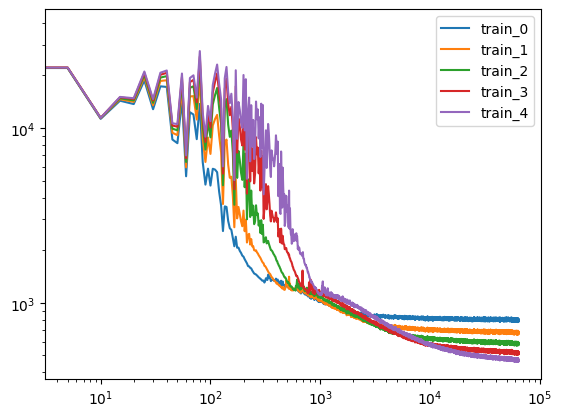

In [4]:
for i, logs in enumerate(baseline_trainer_logs):
    plt.plot(logs['step'], logs['l2_loss'], label=f'train_{i}')

plt.xscale('log')
plt.yscale('log')
# plt.xlim(2e2, None)
# plt.ylim(None, 2e3)
plt.legend()

Text(0, 0.5, 'Reconstruction MSE')

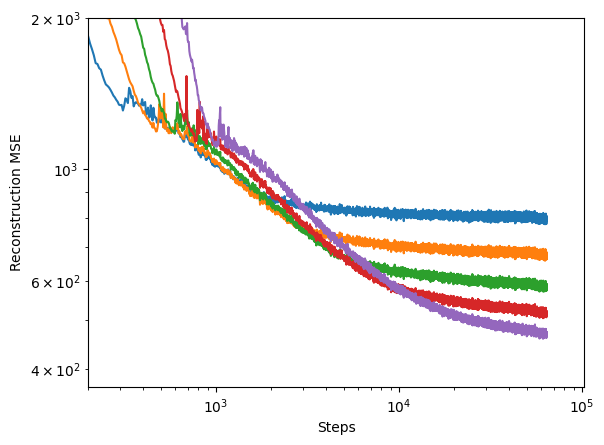

In [5]:
for i, logs in enumerate(baseline_trainer_logs):
    plt.plot(logs['step'], logs['l2_loss'], label=f'train_{i}')

plt.xscale('log')
plt.yscale('log')
plt.xlim(2e2, None)
plt.ylim(None, 2e3)
plt.xlabel("Steps")
plt.ylabel("Reconstruction MSE")

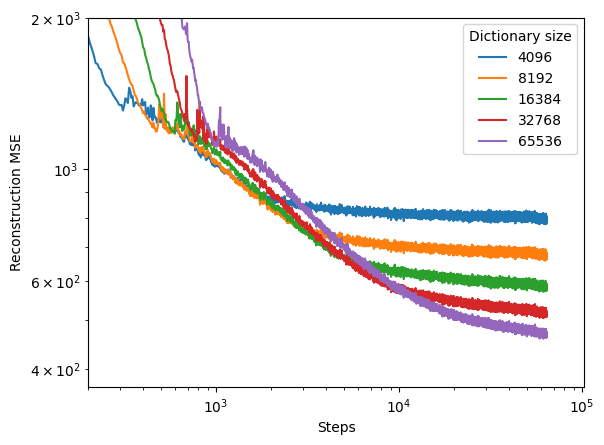

In [6]:
for i in range(5):
    log = load_jsonl(f"../experiments/topk_baselines4/dictionaries/trainer_{i}/logs.jsonl")
    with open(f"../experiments/topk_baselines2/dictionaries/trainer_{i}/config.json") as f:
        config = json.load(f)
    plt.plot(log['step'], log['l2_loss'], label=f"{config['trainer']['dict_size']}")

plt.xscale('log')
plt.yscale('log')
plt.xlim(2e2, None)
plt.ylim(None, 2e3)
plt.xlabel("Steps")
plt.ylabel("Reconstruction MSE")
plt.legend(title="Dictionary size")

Text(0.5, 1.0, 'Scaling wrt dictionary size')

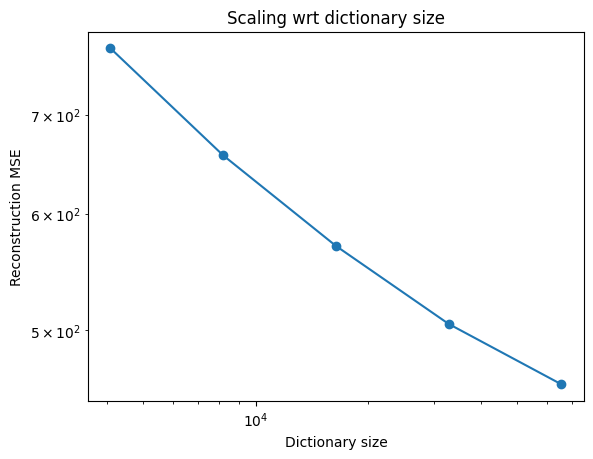

In [7]:
# plot the scaling curve reconstruction mse vs dictionary size (min loss across steps)
dict_sizes = []
min_l2_losses = []
for i in range(5):
    log = load_jsonl(f"../experiments/topk_baselines4/dictionaries/trainer_{i}/logs.jsonl")
    with open(f"../experiments/topk_baselines4/dictionaries/trainer_{i}/config.json") as f:
        config = json.load(f)
    dict_sizes.append(config['trainer']['dict_size'])
    min_l2_losses.append(np.min(log['l2_loss']))

plt.plot(dict_sizes, min_l2_losses, 'o-')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Dictionary size")
plt.ylabel("Reconstruction MSE")
plt.title("Scaling wrt dictionary size")

Text(0, 0.5, 'Reconstruction MSE')

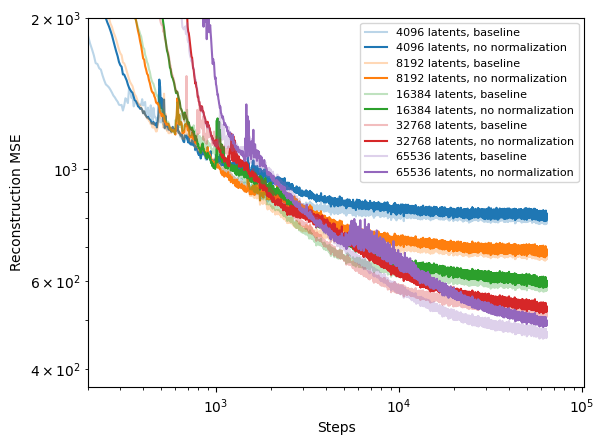

In [8]:
for i in range(5):
    with_normalization_log = load_jsonl(f"../experiments/topk_baselines4/dictionaries/trainer_{i}/logs.jsonl")
    with open(f"../experiments/topk_baselines4/dictionaries/trainer_{i}/config.json") as f:
        with_normalization_config = json.load(f)
    no_normalization_log = load_jsonl(f"../experiments/topk_baselines5/dictionaries/trainer_{i}/logs.jsonl")
    with open(f"../experiments/topk_baselines5/dictionaries/trainer_{i}/config.json") as f:
        no_normalization_config = json.load(f)
    plt.plot(with_normalization_log['step'], with_normalization_log['l2_loss'], label=f"{with_normalization_config['trainer']['dict_size']} latents, baseline", color=f'C{i}', alpha=0.3)
    plt.plot(no_normalization_log['step'], no_normalization_log['l2_loss'], label=f"{no_normalization_config['trainer']['dict_size']} latents, no normalization", color=f'C{i}')

plt.xscale('log')
plt.yscale('log')
plt.legend(prop={'size': 8})
plt.xlim(2e2, None)
plt.ylim(None, 2e3)
plt.xlabel("Steps")
plt.ylabel("Reconstruction MSE")

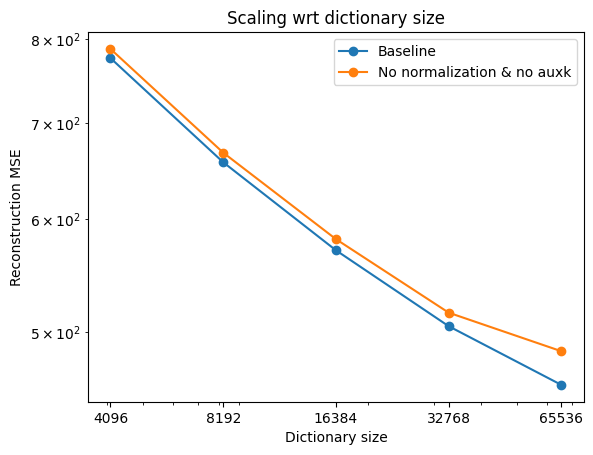

In [9]:
# plot scaling curve, first for baseline, then for no normalization
dict_sizes = []
min_l2_losses = []
for i in range(5):
    log = load_jsonl(f"../experiments/topk_baselines4/dictionaries/trainer_{i}/logs.jsonl")
    with open(f"../experiments/topk_baselines4/dictionaries/trainer_{i}/config.json") as f:
        config = json.load(f)
    dict_sizes.append(config['trainer']['dict_size'])
    min_l2_losses.append(np.min(log['l2_loss']))

plt.plot(dict_sizes, min_l2_losses, 'o-', label="Baseline")

dict_sizes = []
min_l2_losses = []
for i in range(5):
    log = load_jsonl(f"../experiments/topk_baselines5/dictionaries/trainer_{i}/logs.jsonl")
    with open(f"../experiments/topk_baselines5/dictionaries/trainer_{i}/config.json") as f:
        config = json.load(f)
    dict_sizes.append(config['trainer']['dict_size'])
    min_l2_losses.append(np.min(log['l2_loss']))

plt.plot(dict_sizes, min_l2_losses, 'o-', label="No normalization & no auxk")

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Dictionary size")
plt.ylabel("Reconstruction MSE")
plt.title("Scaling wrt dictionary size")
plt.xticks(dict_sizes, dict_sizes)
plt.legend()

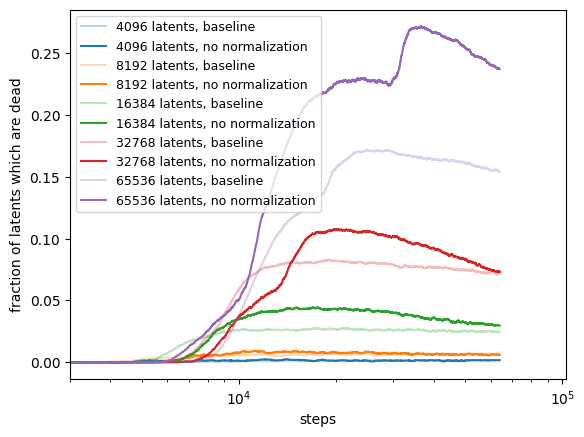

In [12]:
# plot number of dead latents
for i in range(5):
    with_normalization_log = load_jsonl(f"../experiments/topk_baselines4/dictionaries/trainer_{i}/logs.jsonl")
    with open(f"../experiments/topk_baselines4/dictionaries/trainer_{i}/config.json") as f:
        with_normalization_config = json.load(f)
    no_normalization_log = load_jsonl(f"../experiments/topk_baselines5/dictionaries/trainer_{i}/logs.jsonl")
    with open(f"../experiments/topk_baselines5/dictionaries/trainer_{i}/config.json") as f:
        no_normalization_config = json.load(f)
    
    with_normalization_dead_latents_frac = np.array(with_normalization_log['dead_features']) / with_normalization_config['trainer']['dict_size']
    no_normalization_dead_latents_frac = np.array(no_normalization_log['dead_features']) / no_normalization_config['trainer']['dict_size']

    plt.plot(with_normalization_log['step'], with_normalization_dead_latents_frac, label=f"{with_normalization_config['trainer']['dict_size']} latents, baseline", color=f'C{i}', alpha=0.3)
    plt.plot(no_normalization_log['step'], no_normalization_dead_latents_frac, label=f"{no_normalization_config['trainer']['dict_size']} latents, no normalization", color=f'C{i}')
plt.ylabel('fraction of latents which are dead')
plt.xscale('log')
# plt.yscale('log')
plt.xlim(3e3, None)
plt.xlabel('steps')
plt.legend(prop={'size': 9})

### Low-rank structured SAEs

Text(0.5, 1.0, 'Low Rank SAEs')

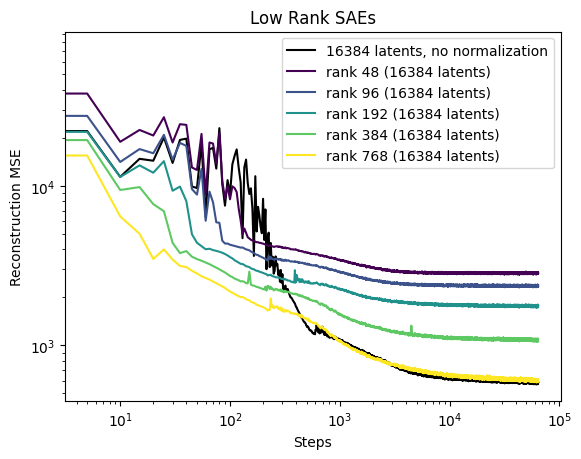

In [18]:
# let's first plot the baseline with 16k features
baseline_log = load_jsonl(f"../experiments/topk_baselines4/dictionaries/trainer_2/logs.jsonl")
with open(f"../experiments/topk_baselines3/dictionaries/trainer_2/config.json") as f:
    baseline_config = json.load(f)
plt.plot(baseline_log['step'], baseline_log['l2_loss'], label=f"{baseline_config['trainer']['dict_size']} latents, no normalization", color='black', alpha=1.0)

colors = plt.cm.viridis(np.linspace(0, 1, 5))
for i in range(5):
    log = load_jsonl(f"../experiments/topk_low_rank2/dictionaries/trainer_{i}/logs.jsonl")
    with open(f"../experiments/topk_low_rank2/dictionaries/trainer_{i}/config.json") as f:
        config = json.load(f)
    plt.plot(log['step'], log['l2_loss'], label=f"rank {config['trainer']['rank']} ({config['trainer']['dict_size']} latents)", color=colors[i])

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Steps')
plt.ylabel('Reconstruction MSE')
plt.legend()
plt.title("Low Rank SAEs")

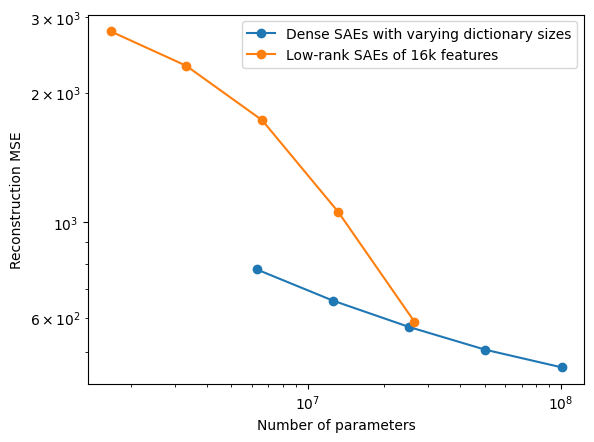

In [19]:
# plot scaling curve for baseline and for low-rank, in terms of number of parameters
parameters = []
min_l2_losses = []
for i in range(5):
    log = load_jsonl(f"../experiments/topk_baselines4/dictionaries/trainer_{i}/logs.jsonl")
    with open(f"../experiments/topk_baselines4/dictionaries/trainer_{i}/config.json") as f:
        config = json.load(f)
    p = 768 * config['trainer']['dict_size'] * 2 + 768 + config['trainer']['dict_size'] # 2 786xdict_size matrices plus two biases
    parameters.append(p)
    min_l2_losses.append(np.min(log['l2_loss']))

plt.plot(parameters, min_l2_losses, 'o-', label="Dense SAEs with varying dictionary sizes")

parameters = []
min_l2_losses = []
for i in range(5):
    log = load_jsonl(f"../experiments/topk_low_rank2/dictionaries/trainer_{i}/logs.jsonl")
    with open(f"../experiments/topk_low_rank2/dictionaries/trainer_{i}/config.json") as f:
        config = json.load(f)
    rank = config['trainer']['rank']
    p = (786 * rank + rank * config['trainer']['dict_size']) * 2 + 768 + config['trainer']['dict_size']
    parameters.append(p)
    min_l2_losses.append(np.min(log['l2_loss']))

plt.plot(parameters, min_l2_losses, 'o-', label="Low-rank SAEs of 16k features")

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Number of parameters")
plt.ylabel("Reconstruction MSE")
plt.legend()


Text(0.5, 1.0, 'Low Rank (96) SAE (16k features) with varying learning rates')

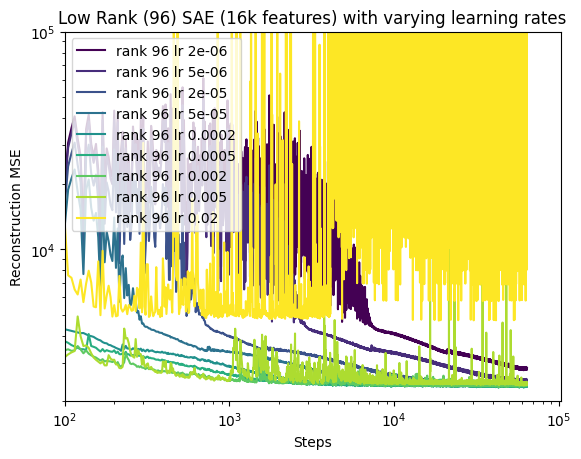

In [22]:
# sanity check: make sure our choice of learning rate isn't screwing us
colors = plt.cm.viridis(np.linspace(0, 1, 9))
for i in range(9):
    log = load_jsonl(f"../experiments/topk_low_rank3/dictionaries/trainer_{i}/logs.jsonl")
    with open(f"../experiments/topk_low_rank3/dictionaries/trainer_{i}/config.json") as f:
        config = json.load(f)
    plt.plot(log['step'], log['l2_loss'], label=f"rank {config['trainer']['rank']} lr {config['trainer']['lr']}", color=colors[i])

plt.xscale('log')
plt.yscale('log')
plt.xlim(1e2, None)
plt.ylim(2e3, 1e5)
plt.xlabel('Steps')
plt.ylabel('Reconstruction MSE')
plt.legend()
plt.title("Low Rank (96) SAE (16k features) with varying learning rates")

Text(0.5, 1.0, 'Low Rank (96) SAE (16k features) with varying learning rates')

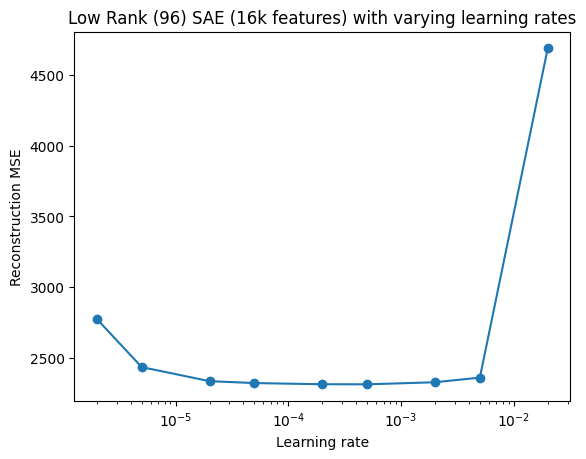

In [23]:
# just plot the minimum loss for each of the learning rates
lrs = []
min_l2_losses = []
for i in range(9):
    log = load_jsonl(f"../experiments/topk_low_rank3/dictionaries/trainer_{i}/logs.jsonl")
    with open(f"../experiments/topk_low_rank3/dictionaries/trainer_{i}/config.json") as f:
        config = json.load(f)
    lrs.append(config['trainer']['lr'])
    min_l2_losses.append(np.min(log['l2_loss']))

plt.plot(lrs, min_l2_losses, 'o-')
plt.xscale('log')
plt.xlabel("Learning rate")
plt.ylabel("Reconstruction MSE")
plt.title("Low Rank (96) SAE (16k features) with varying learning rates")

### Visualize sum kronecker SAEs performance

In [17]:
config['trainer']['dict_size']

16384

(462.5313736477733, 3000.0)

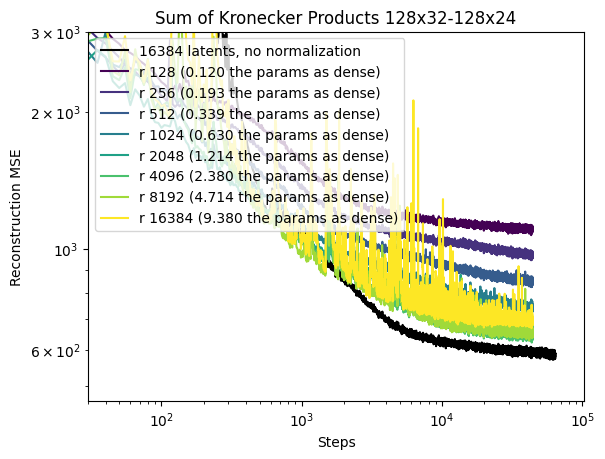

In [27]:

# let's first plot the baseline with 16k features
baseline_log = load_jsonl(f"../experiments/topk_baselines4/dictionaries/trainer_2/logs.jsonl")
with open(f"../experiments/topk_baselines3/dictionaries/trainer_2/config.json") as f:
    baseline_config = json.load(f)
plt.plot(baseline_log['step'], baseline_log['l2_loss'], label=f"{baseline_config['trainer']['dict_size']} latents, no normalization", color='black', alpha=1.0)

d1, d2, d3, d4 = 128, 32, 128, 24
n_rs = len(os.listdir(f"../experiments/topk_sum_kronecker0/{d1}x{d2}-{d3}x{d4}"))
colors = plt.cm.viridis(np.linspace(0, 1, n_rs))
for i in range(n_rs):
    log = load_jsonl(f"../experiments/topk_sum_kronecker0/{d1}x{d2}-{d3}x{d4}/trainer_{i}/logs.jsonl")
    with open(f"../experiments/topk_sum_kronecker0/{d1}x{d2}-{d3}x{d4}/trainer_{i}/config.json") as f:
        config = json.load(f)
    parameters = (d1 * d2 + d3 * d4) * config['trainer']['r'] + (config['trainer']['activation_dim'] ** 2)
    frac_parameters = parameters / (config['trainer']['dict_size'] * config['trainer']['activation_dim'])
    plt.plot(log['step'], log['l2_loss'], label=f"r {config['trainer']['r']} ({frac_parameters:.3f} the params as dense)", color=colors[i])

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Steps')
plt.ylabel('Reconstruction MSE')
plt.legend()
# plt.title("Sum of Kronecker Products")
plt.title(f"Sum of Kronecker Products {d1}x{d2}-{d3}x{d4}")
plt.xlim(3e1, None)
plt.ylim(None, 3e3)

(462.5313736477733, 3000.0)

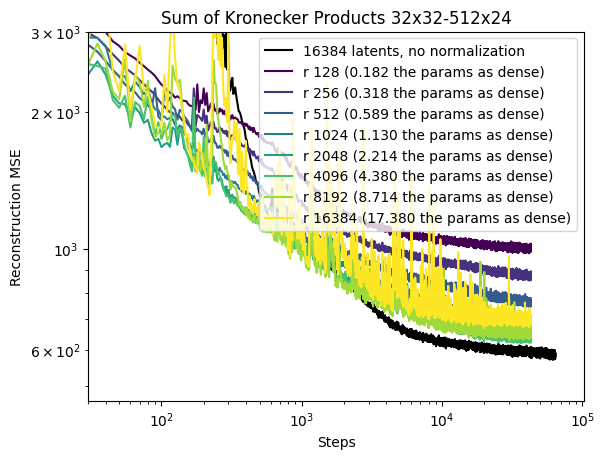

In [26]:

# let's first plot the baseline with 16k features
baseline_log = load_jsonl(f"../experiments/topk_baselines4/dictionaries/trainer_2/logs.jsonl")
with open(f"../experiments/topk_baselines3/dictionaries/trainer_2/config.json") as f:
    baseline_config = json.load(f)
plt.plot(baseline_log['step'], baseline_log['l2_loss'], label=f"{baseline_config['trainer']['dict_size']} latents, no normalization", color='black', alpha=1.0)

d1, d2, d3, d4 = 32, 32, 512, 24
n_rs = len(os.listdir(f"../experiments/topk_sum_kronecker0/{d1}x{d2}-{d3}x{d4}"))
colors = plt.cm.viridis(np.linspace(0, 1, n_rs))
for i in range(n_rs):
    log = load_jsonl(f"../experiments/topk_sum_kronecker0/{d1}x{d2}-{d3}x{d4}/trainer_{i}/logs.jsonl")
    with open(f"../experiments/topk_sum_kronecker0/{d1}x{d2}-{d3}x{d4}/trainer_{i}/config.json") as f:
        config = json.load(f)
    parameters = (d1 * d2 + d3 * d4) * config['trainer']['r'] + (config['trainer']['activation_dim'] ** 2)
    frac_parameters = parameters / (config['trainer']['dict_size'] * config['trainer']['activation_dim'])
    plt.plot(log['step'], log['l2_loss'], label=f"r {config['trainer']['r']} ({frac_parameters:.3f} the params as dense)", color=colors[i])

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Steps')
plt.ylabel('Reconstruction MSE')
plt.legend()
plt.title(f"Sum of Kronecker Products {d1}x{d2}-{d3}x{d4}")
plt.xlim(3e1, None)
plt.ylim(None, 3e3)

(462.5313736477733, 3000.0)

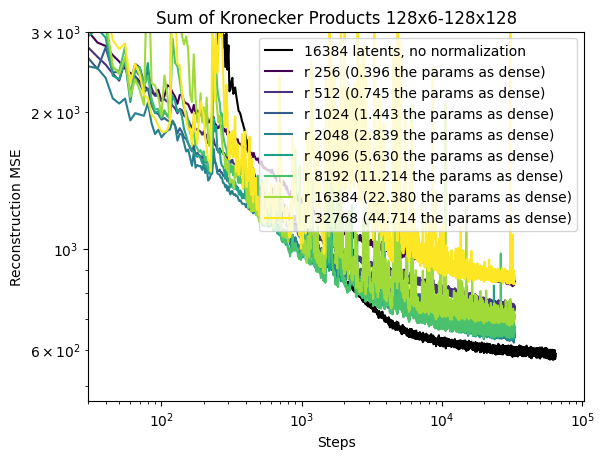

In [28]:
# let's first plot the baseline with 16k features
baseline_log = load_jsonl(f"../experiments/topk_baselines4/dictionaries/trainer_2/logs.jsonl")
with open(f"../experiments/topk_baselines3/dictionaries/trainer_2/config.json") as f:
    baseline_config = json.load(f)
plt.plot(baseline_log['step'], baseline_log['l2_loss'], label=f"{baseline_config['trainer']['dict_size']} latents, no normalization", color='black', alpha=1.0)

d1, d2, d3, d4 = 128, 6, 128, 128
n_rs = len(os.listdir(f"../experiments/topk_sum_kronecker0/{d1}x{d2}-{d3}x{d4}"))
colors = plt.cm.viridis(np.linspace(0, 1, n_rs))
for i in range(n_rs):
    log = load_jsonl(f"../experiments/topk_sum_kronecker0/{d1}x{d2}-{d3}x{d4}/trainer_{i}/logs.jsonl")
    with open(f"../experiments/topk_sum_kronecker0/{d1}x{d2}-{d3}x{d4}/trainer_{i}/config.json") as f:
        config = json.load(f)
    parameters = (d1 * d2 + d3 * d4) * config['trainer']['r'] + (config['trainer']['activation_dim'] ** 2)
    frac_parameters = parameters / (config['trainer']['dict_size'] * config['trainer']['activation_dim'])
    plt.plot(log['step'], log['l2_loss'], label=f"r {config['trainer']['r']} ({frac_parameters:.3f} the params as dense)", color=colors[i])

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Steps')
plt.ylabel('Reconstruction MSE')
plt.legend()
plt.title(f"Sum of Kronecker Products {d1}x{d2}-{d3}x{d4}")
plt.xlim(3e1, None)
plt.ylim(None, 3e3)

(462.5313736477733, 3000.0)

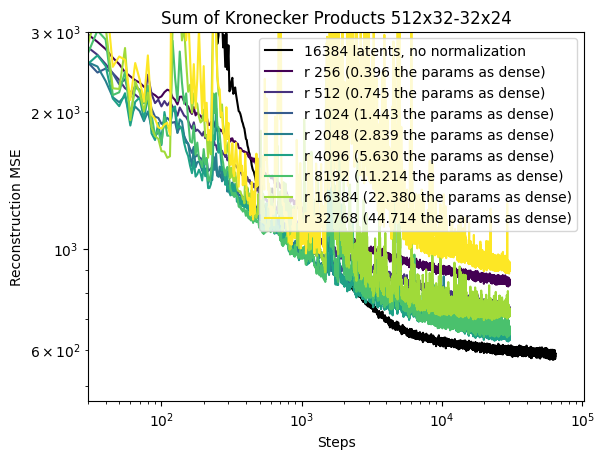

In [29]:
# let's first plot the baseline with 16k features
baseline_log = load_jsonl(f"../experiments/topk_baselines4/dictionaries/trainer_2/logs.jsonl")
with open(f"../experiments/topk_baselines3/dictionaries/trainer_2/config.json") as f:
    baseline_config = json.load(f)
plt.plot(baseline_log['step'], baseline_log['l2_loss'], label=f"{baseline_config['trainer']['dict_size']} latents, no normalization", color='black', alpha=1.0)

d1, d2, d3, d4 = 512, 32, 32, 24
n_rs = len(os.listdir(f"../experiments/topk_sum_kronecker0/{d1}x{d2}-{d3}x{d4}"))
colors = plt.cm.viridis(np.linspace(0, 1, n_rs))
for i in range(n_rs):
    log = load_jsonl(f"../experiments/topk_sum_kronecker0/{d1}x{d2}-{d3}x{d4}/trainer_{i}/logs.jsonl")
    with open(f"../experiments/topk_sum_kronecker0/{d1}x{d2}-{d3}x{d4}/trainer_{i}/config.json") as f:
        config = json.load(f)
    parameters = (d1 * d2 + d3 * d4) * config['trainer']['r'] + (config['trainer']['activation_dim'] ** 2)
    frac_parameters = parameters / (config['trainer']['dict_size'] * config['trainer']['activation_dim'])
    plt.plot(log['step'], log['l2_loss'], label=f"r {config['trainer']['r']} ({frac_parameters:.3f} the params as dense)", color=colors[i])

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Steps')
plt.ylabel('Reconstruction MSE')
plt.legend()
plt.title(f"Sum of Kronecker Products {d1}x{d2}-{d3}x{d4}")
plt.xlim(3e1, None)
plt.ylim(None, 3e3)

### Block diagonal SAEs

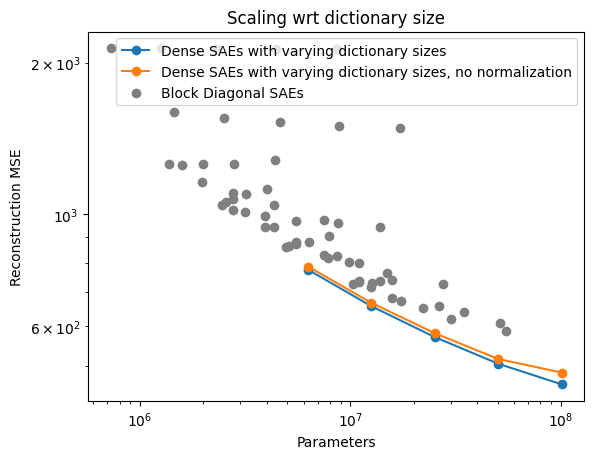

In [9]:
# plot scaling curve for baseline with normalization
parameters = []
min_l2_losses = []
for i in range(5):
    log = load_jsonl(f"../experiments/topk_baselines4/dictionaries/trainer_{i}/logs.jsonl")
    with open(f"../experiments/topk_baselines4/dictionaries/trainer_{i}/config.json") as f:
        config = json.load(f)
    p = 768 * config['trainer']['dict_size'] * 2 + 768 + config['trainer']['dict_size'] # 2 786xdict_size matrices plus two biases
    parameters.append(p)
    min_l2_losses.append(np.min(log['l2_loss']))

plt.plot(parameters, min_l2_losses, 'o-', label="Dense SAEs with varying dictionary sizes")

# scaling curve for no normalization
parameters = []
min_l2_losses = []
for i in range(5):
    log = load_jsonl(f"../experiments/topk_baselines5/dictionaries/trainer_{i}/logs.jsonl")
    with open(f"../experiments/topk_baselines5/dictionaries/trainer_{i}/config.json") as f:
        config = json.load(f)
    p = 768 * config['trainer']['dict_size'] * 2 + 768 + config['trainer']['dict_size'] # 2 786xdict_size matrices plus two biases
    parameters.append(p)
    min_l2_losses.append(np.min(log['l2_loss']))

plt.plot(parameters, min_l2_losses, 'o-', label="Dense SAEs with varying dictionary sizes, no normalization")


# now load up block diagonal results
dict_sizes = [4_096, 8_192, 16_384, 32_768, 65_536]
for dict_size in dict_sizes:
    trainers = os.listdir(f"../experiments/topk_block_diagonal0/dict_size{dict_size}")
    min_l2_losses = []
    parameters = []
    for trainer in trainers:
        log = load_jsonl(f"../experiments/topk_block_diagonal0/dict_size{dict_size}/{trainer}/logs.jsonl")
        with open(f"../experiments/topk_block_diagonal0/dict_size{dict_size}/{trainer}/config.json") as f:
            config = json.load(f)
        min_l2_losses.append(np.min(log['l2_loss']))
        ds = config['trainer']['dict_size']
        assert ds == dict_size
        activation_dim = config['trainer']['activation_dim']
        proj_dim = config['trainer']['proj_dim']
        blocks = config['trainer']['blocks']
        p = (activation_dim * proj_dim + (blocks * (proj_dim // blocks) * (ds // blocks))) * 2 + activation_dim + ds
        parameters.append(p)
    plt.scatter(parameters, min_l2_losses, color='grey', label="Block Diagonal SAEs" if dict_size == dict_sizes[0] else None)

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Parameters")
plt.ylabel("Reconstruction MSE")
plt.title("Scaling wrt dictionary size")
# plt.xticks(dict_sizes, dict_sizes)
plt.legend()

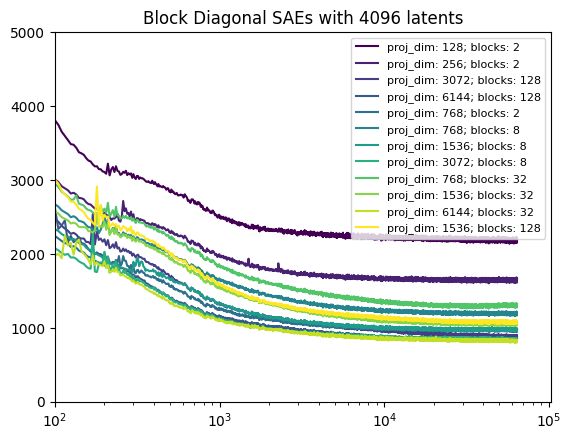

In [17]:
# actually visualize the learning curves for a bunch of these
dict_size = 4_096

trainers = os.listdir(f"../experiments/topk_block_diagonal0/dict_size{dict_size}")
colors = plt.cm.viridis(np.linspace(0, 1, len(trainers)))
for i, trainer in enumerate(trainers):
    log = load_jsonl(f"../experiments/topk_block_diagonal0/dict_size{dict_size}/{trainer}/logs.jsonl")
    with open(f"../experiments/topk_block_diagonal0/dict_size{dict_size}/{trainer}/config.json") as f:
        config = json.load(f)
    blocks = config['trainer']['blocks']
    proj_dim = config['trainer']['proj_dim']
    plt.plot(log['step'], log['l2_loss'], label=f"proj_dim: {proj_dim}; blocks: {blocks}", color=colors[i])

plt.xscale('log')
plt.xlim(1e2, None)
plt.ylim(0, 5e3)
plt.title(f"Block Diagonal SAEs with {dict_size} latents")
plt.legend(prop={'size': 8}, loc='upper right')

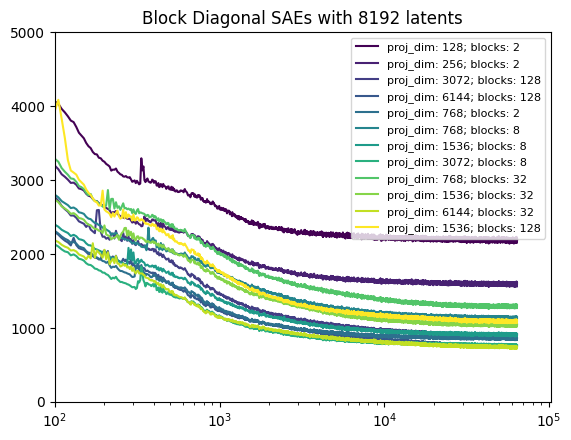

In [18]:
# actually visualize the learning curves for a bunch of these
dict_size = 8_192

trainers = os.listdir(f"../experiments/topk_block_diagonal0/dict_size{dict_size}")
colors = plt.cm.viridis(np.linspace(0, 1, len(trainers)))
for i, trainer in enumerate(trainers):
    log = load_jsonl(f"../experiments/topk_block_diagonal0/dict_size{dict_size}/{trainer}/logs.jsonl")
    with open(f"../experiments/topk_block_diagonal0/dict_size{dict_size}/{trainer}/config.json") as f:
        config = json.load(f)
    blocks = config['trainer']['blocks']
    proj_dim = config['trainer']['proj_dim']
    plt.plot(log['step'], log['l2_loss'], label=f"proj_dim: {proj_dim}; blocks: {blocks}", color=colors[i])

plt.xscale('log')
plt.xlim(1e2, None)
plt.ylim(0, 5e3)
plt.title(f"Block Diagonal SAEs with {dict_size} latents")
plt.legend(prop={'size': 8}, loc='upper right')

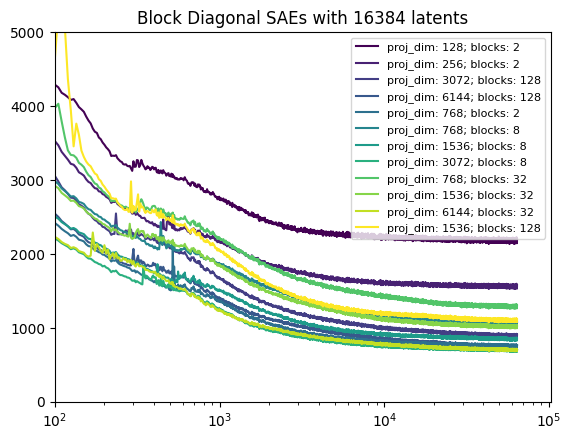

In [16]:
# actually visualize the learning curves for a bunch of these
dict_size = 16_384

trainers = os.listdir(f"../experiments/topk_block_diagonal0/dict_size{dict_size}")
colors = plt.cm.viridis(np.linspace(0, 1, len(trainers)))
for i, trainer in enumerate(trainers):
    log = load_jsonl(f"../experiments/topk_block_diagonal0/dict_size{dict_size}/{trainer}/logs.jsonl")
    with open(f"../experiments/topk_block_diagonal0/dict_size{dict_size}/{trainer}/config.json") as f:
        config = json.load(f)
    blocks = config['trainer']['blocks']
    proj_dim = config['trainer']['proj_dim']
    plt.plot(log['step'], log['l2_loss'], label=f"proj_dim: {proj_dim}; blocks: {blocks}", color=colors[i])

plt.xscale('log')
plt.xlim(1e2, None)
plt.ylim(0, 5e3)
plt.title(f"Block Diagonal SAEs with {dict_size} latents")
plt.legend(prop={'size': 8}, loc='upper right')

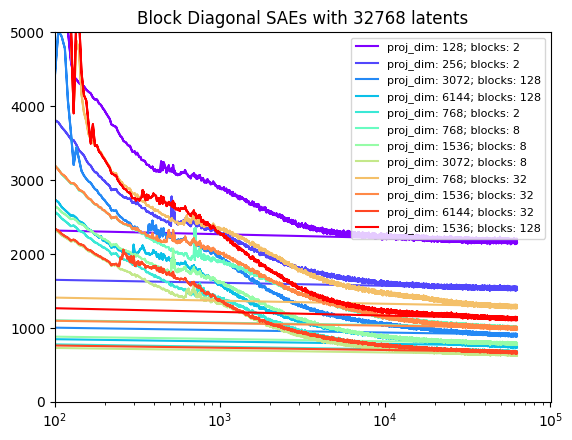

In [20]:
# actually visualize the learning curves for a bunch of these
dict_size = 32_768

trainers = os.listdir(f"../experiments/topk_block_diagonal0/dict_size{dict_size}")
colors = plt.cm.rainbow(np.linspace(0, 1, len(trainers)))
for i, trainer in enumerate(trainers):
    log = load_jsonl(f"../experiments/topk_block_diagonal0/dict_size{dict_size}/{trainer}/logs.jsonl")
    with open(f"../experiments/topk_block_diagonal0/dict_size{dict_size}/{trainer}/config.json") as f:
        config = json.load(f)
    blocks = config['trainer']['blocks']
    proj_dim = config['trainer']['proj_dim']
    plt.plot(log['step'], log['l2_loss'], label=f"proj_dim: {proj_dim}; blocks: {blocks}", color=colors[i])

plt.xscale('log')
plt.xlim(1e2, None)
plt.ylim(0, 5e3)
plt.title(f"Block Diagonal SAEs with {dict_size} latents")
plt.legend(prop={'size': 8}, loc='upper right')

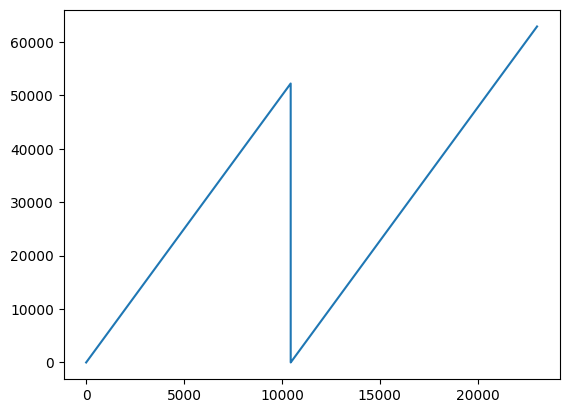

In [21]:
plt.plot(log['step'])

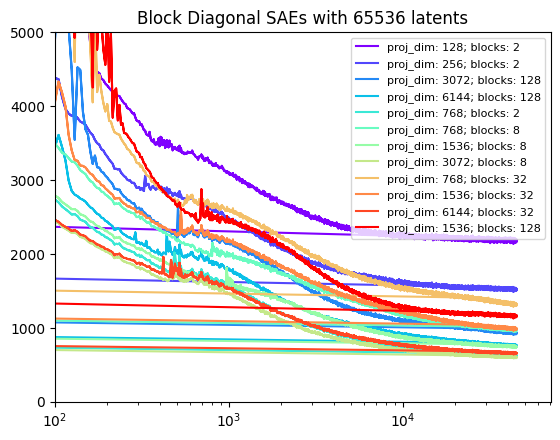

In [22]:
# actually visualize the learning curves for a bunch of these
dict_size = 65_536

trainers = os.listdir(f"../experiments/topk_block_diagonal0/dict_size{dict_size}")
colors = plt.cm.rainbow(np.linspace(0, 1, len(trainers)))
for i, trainer in enumerate(trainers):
    log = load_jsonl(f"../experiments/topk_block_diagonal0/dict_size{dict_size}/{trainer}/logs.jsonl")
    with open(f"../experiments/topk_block_diagonal0/dict_size{dict_size}/{trainer}/config.json") as f:
        config = json.load(f)
    blocks = config['trainer']['blocks']
    proj_dim = config['trainer']['proj_dim']
    plt.plot(log['step'], log['l2_loss'], label=f"proj_dim: {proj_dim}; blocks: {blocks}", color=colors[i])

plt.xscale('log')
plt.xlim(1e2, None)
plt.ylim(0, 5e3)
plt.title(f"Block Diagonal SAEs with {dict_size} latents")
plt.legend(prop={'size': 8}, loc='upper right')

### Sum Kronecker

In [24]:
import re

In [25]:
exp_dir = "../experiments/topk_sum_kronecker1"
# get all subdirectories which are like 32x32-512x24 (with the numbers being whatever)
directories = os.listdir(exp_dir)
directories = [d for d in directories if re.match(r"\d+x\d+-\d+x\d+", d)]
directories = [os.path.join(exp_dir, d) for d in directories]
for shape_dir in directories:
    trainers = os.listdir(shape_dir)
    min_l2_losses = []
    parameters = []
    for trainer in trainers:
        log = load_jsonl(os.path.join(shape_dir, trainer, "logs.jsonl"))
        with open(os.path.join(shape_dir, trainer, "config.json")) as f:
            config = json.load(f)
        min_l2_losses.append(np.min(log['l2_loss']))
        d1, d2, d3, d4 = [int(x) for x in re.match(r"(\d+)x(\d+)-(\d+)x(\d+)", os.path.basename(shape_dir)).groups()]
        assert d1 == config['trainer']['d1']
        assert d2 == config['trainer']['d2']
        assert d3 == config['trainer']['d3']
        assert d4 == config['trainer']['d4']
        r = config['trainer']['r']
        activation_dim = config['trainer']['activation_dim']
        dict_size = config['trainer']['dict_size']
        p = ((d1 * d2 + d3 * d4) * r + (activation_dim ** 2)) * 2 + activation_dim + dict_size
        parameters.append(p)
    plt.scatter(parameters, min_l2_losses, color='grey', label=os.path.basename(shape_dir))






In [27]:
directories

['128x128-128x6',
 '128x32-128x24',
 '128x6-128x128',
 '2048x32-8x24',
 '32x32-512x24',
 '32x6-512x128',
 '512x128-32x6',
 '512x32-32x24',
 '8x32-2048x24']